### Import Packages

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from keras.models import Model, load_model
from keras.layers import Input, LSTM, Dense, MultiHeadAttention, GlobalAveragePooling1D, Masking
from keras.optimizers import Adam
from keras.saving import register_keras_serializable

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version: ", tf.__version__)
print("Number of GPUs available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow version:  2.19.0
Number of GPUs available:  1


### Data Preprocessing

In [3]:
cols = ['u','u_e','u_n']
scaled_cols = ['scaled_' + col for col in cols]

# Load datasets
df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

# df_test: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
split = pd.to_datetime('2024-06-30 23:59:00')
df_stn_train = df_stn[df_stn.index < split]
df_stn_test = df_stn[df_stn.index > split]

df_buoy_train = df_buoy[df_buoy.index < split]
df_buoy_test = df_buoy[df_buoy.index > split]

# Data normalization
scaled_stn_wind, scaled_wind, scaled_wave = MinMaxScaler(), MinMaxScaler(), MinMaxScaler()
df_stn_train, df_stn_test = df_stn_train.copy(), df_stn_test.copy()
df_stn_train.loc[:, scaled_cols] = scaled_stn_wind.fit_transform(df_stn_train[cols])
df_stn_test.loc[:, scaled_cols] = scaled_stn_wind.transform(df_stn_test[cols])

df_buoy_train, df_buoy_test = df_buoy_train.copy(), df_buoy_test.copy()
df_buoy_train.loc[:, scaled_cols] = scaled_wind.fit_transform(df_buoy_train[cols])
df_buoy_test.loc[:, scaled_cols] = scaled_wind.transform(df_buoy_test[cols])
df_buoy_train.loc[:, 'scaled_H'] = scaled_wave.fit_transform(df_buoy_train[['H']])
df_buoy_test.loc[:, 'scaled_H'] = scaled_wave.transform(df_buoy_test[['H']])

### Data Preparation: Train-Test-Validation Split

In [4]:
step, output = 24, 12
features = ['scaled_H'] + scaled_cols
wind_model = load_model('wind_transform.keras')

def create_sequences(df_buoy, df_stn, step, output):
    wind_T = wind_model.predict(df_stn[scaled_cols], verbose=0)
    X, y = [], []
    periods = step + output
    for i in range(len(df_buoy) - periods + 1):
        window = df_buoy.iloc[i:(i+periods)]
        expect = pd.date_range(start=window.index[0], periods=periods, freq='h')
        if not window.index.equals(expect):
            continue
        X_seq = window.values.copy()
        X_seq[step:, 0] = -1
        X_seq[step:, 1:] = wind_T[(i+step):(i+periods)]
        X.append(X_seq)
        y.append(window.iloc[step:, 0].values)
    return np.array(X), np.array(y)

# Validation set: [2007-11-01 00:00:00 ~ 2008-10-31 23:00:00]
split1 = pd.to_datetime('2007-10-31 23:59:00')
split2 = pd.to_datetime('2008-10-31 23:59:00')
df_stn_val = df_stn_train[(df_stn_train.index > split1) & (df_stn_train.index < split2)]
df_stn_train = df_stn_train[(df_stn_train.index < split1) | (df_stn_train.index > split2)]
df_buoy_val = df_buoy_train[(df_buoy_train.index > split1) & (df_buoy_train.index < split2)]
df_buoy_train = df_buoy_train[(df_buoy_train.index < split1) | (df_buoy_train.index > split2)]

X_val, y_val = create_sequences(df_buoy_val[features], df_stn_val[scaled_cols], step, output)
X_test, y_test = create_sequences(df_buoy_test[features], df_stn_test[scaled_cols], step, output)

print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

I0000 00:00:1755536731.457056 2258972 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38483 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:25:00.0, compute capability: 8.0
I0000 00:00:1755536732.658830 2259072 service.cc:152] XLA service 0x7f83b4014930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755536732.658864 2259072 service.cc:160]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
I0000 00:00:1755536732.683663 2259072 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1755536732.776543 2259072 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


(8749, 36, 4) (8749, 12)
(8725, 36, 4) (8725, 12)


### Model Selection and Implementation

In [5]:
# Add future wind noise
def add_noise(df, abs_std, rel_std, random_seed=42):
    rng = np.random.default_rng(random_seed)
    wind = df[cols].to_numpy(dtype=float)
    stds = abs_std + rel_std * wind[:, 0]
    cov = np.array([[1, 0.6], [0.6, 1]])
    L_cov = np.linalg.cholesky(cov)
    z = rng.normal(0, 1, size=(wind.shape[0], 2))
    noise = z @ L_cov.T * stds[:, None]
    nu_e = wind[:, 1] + noise[:, 0]
    nu_n = wind[:, 2] + noise[:, 1]
    nu = np.linalg.norm(np.column_stack([nu_e, nu_n]), axis=1)
    nu = np.maximum(nu, 0.25)
    return pd.DataFrame({'u':nu, 'u_e':nu_e, 'u_n':nu_n}, index=df.index)

# Gaussian NLL loss
@register_keras_serializable()
def gaussian_nll_loss(y_true, y_pred):
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    mean, log_var = tf.split(y_pred, 2, axis=1)
    log_var = tf.clip_by_value(log_var, -10.0, 10.0)
    loss = 0.5 * (log_var + tf.square(y_true-mean) / tf.exp(log_var))
    return tf.reduce_mean(loss)

# Model architecture
def create_model(X):
    # Input layer with shape: (batch_size, time_steps, features)
    input_layer = Input(shape=(X.shape[1], X.shape[2]))

    # Masking layer
    mask_layer = Masking(-1)(input_layer)

    # LSTM layer
    units = 32
    lstm_layer = LSTM(units=128, activation='tanh', return_sequences=True)(mask_layer)
    lstm_out = LSTM(units=units, activation='tanh', return_sequences=True)(lstm_layer)
    
    # Attention layer
    num_heads = 8
    attn_layer = MultiHeadAttention(num_heads=num_heads, key_dim=units//num_heads)
    attn_out, attn_scores = attn_layer(lstm_out, lstm_out, return_attention_scores=True)
    
    # Pooling layer
    pooled_out = GlobalAveragePooling1D()(attn_out)

    # Output layer
    output_layer = Dense(12 * 2)(pooled_out)
    
    # Build model
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss=gaussian_nll_loss)
    attn_model = Model(inputs=input_layer, outputs=attn_scores)
    
    return model, attn_model

In [ ]:
epochs = 100
samples = 10
batch_size = 64
model_file = 'model_aug_uncertainty.keras'

# Train and save the model
model, attn_model = create_model(X_val)
loss, val_loss = [], []
best_val_loss, count = np.inf, 0

for i in range(epochs):
    rng_epoch = np.random.default_rng(i)
    abs_std = rng_epoch.uniform(0, 1.5)
    rel_std = rng_epoch.uniform(0, 0.5)
    epoch_loss, epoch_val_loss = [], []

    for n in range(samples):
        df_noise = add_noise(df_stn_train[cols], abs_std, rel_std, random_seed=100*(i+1)+n)
        df_noise[scaled_cols] = scaled_stn_wind.transform(df_noise)
        X_train, y_train = create_sequences(df_buoy_train[features], df_noise, step, output)

        history = model.fit(X_train, y_train, epochs=1, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)
        epoch_loss.append(history.history['loss'][0])
        epoch_val_loss.append(history.history['val_loss'][0])
    
    loss.append(np.mean(epoch_loss))
    val_loss.append(np.mean(epoch_val_loss))
    print(f'Epoch {i+1}: loss={np.mean(epoch_loss):.4f}, val_loss={np.mean(epoch_val_loss):.4f}')

    # Early stopping
    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        model.save(model_file)
        count = 0
    else:
        count += 1
        if count >= 10:
            break

In [6]:
df = pd.read_csv('loss_2.csv')
loss = df['loss']
val_loss = df['val_loss']

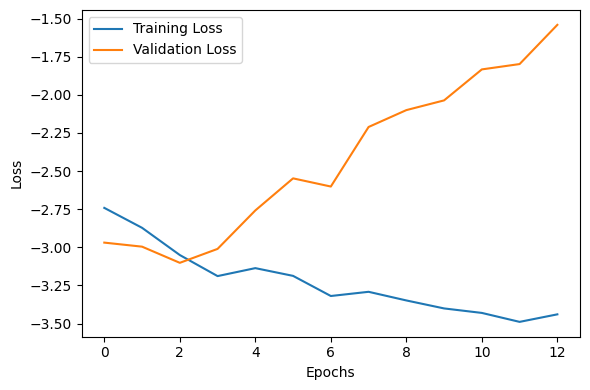

In [7]:
# Plot the training & validation loss over epochs
plt.figure(figsize=(6, 4))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
head_idx = 0
attn_weights = attn_model.predict(X_test, verbose=0)
attn_head_matrix = attn_weights[:, head_idx, :, :]
attn_matrix = np.mean(attn_head_matrix, axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(attn_matrix, cmap='viridis')
plt.xlabel("Key Time Steps")
plt.ylabel("Query Time Steps")

plt.tight_layout()
plt.show()

### Model Evaluation

In [8]:
coef = 1.96
model = load_model('model_aug_uncertainty.keras')
y_true = scaled_wave.inverse_transform(y_test)

# Add future wind noise (change)
abs_std, rel_std = 1.0, 0.5
df_noise = add_noise(df_stn_test[cols], abs_std, rel_std)
df_noise[scaled_cols] = scaled_stn_wind.transform(df_noise)
X_noise = create_sequences(df_buoy_test[features], df_noise, step, output)[0]

# Model predictions (mean + uncertainty)
y_pred = model.predict(X_noise, verbose=0)
mean_pred, log_var_pred = tf.split(y_pred, 2, axis=1)
sigma_pred = np.sqrt(tf.exp(log_var_pred))

# Confidence interval
lower_pred = mean_pred - coef * sigma_pred
upper_pred = mean_pred + coef * sigma_pred
mean_pred_raw  = scaled_wave.inverse_transform(mean_pred)
lower_pred_raw = scaled_wave.inverse_transform(lower_pred)
upper_pred_raw = scaled_wave.inverse_transform(upper_pred)
rmse = np.sqrt(mean_squared_error(y_true, mean_pred_raw))
print(f'Test RMSE: {rmse:.3f}')
rmse_arr = np.sqrt(mean_squared_error(y_true, mean_pred_raw, multioutput='raw_values'))
print('Test RMSE per output:', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr]))

# Statistics
exceed = (y_true < lower_pred_raw) | (y_true > upper_pred_raw)
print(f'Total number of samples: {y_true.shape[0]}')
print('Exceedance per output:', ', '.join([f'{i:d}' for i in np.sum(exceed, axis=0)]))

Test RMSE: 0.491
Test RMSE per output: 0.211, 0.295, 0.391, 0.450, 0.493, 0.508, 0.527, 0.544, 0.566, 0.570, 0.572, 0.601
Total number of samples: 8725
Exceedance per output: 222, 381, 499, 645, 781, 843, 1048, 1059, 1148, 1084, 933, 861


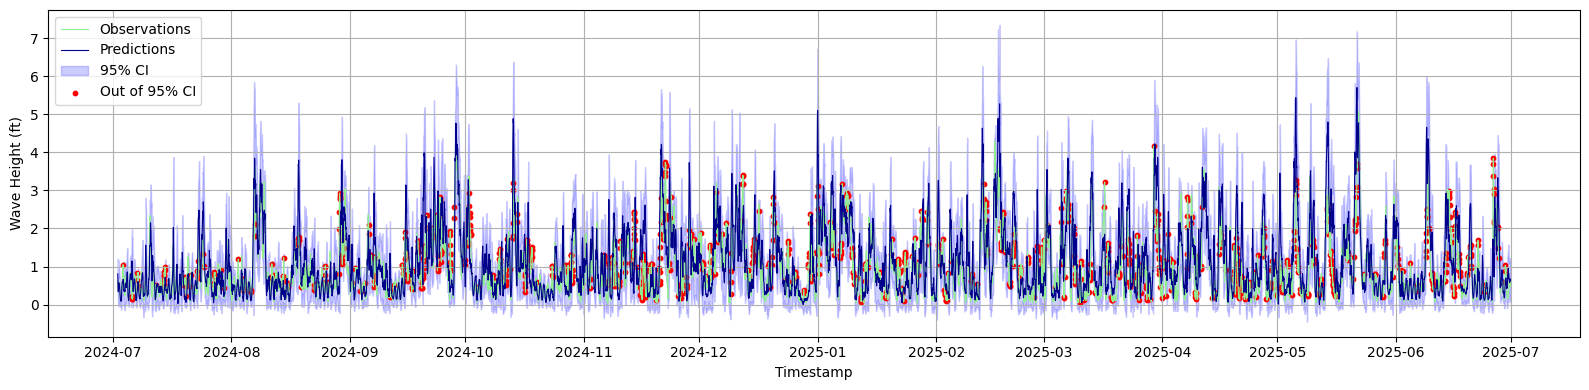

In [9]:
idx = 8
start = step + idx
end = len(df_buoy_test) - (output - idx - 1)

time_idx = df_buoy_test.index[start:end]
y_obs = y_true[:, idx]
y_lower = lower_pred_raw[:, idx]
y_upper = upper_pred_raw[:, idx]
mask = (y_obs < y_lower) | (y_obs > y_upper)

plt.figure(figsize=(16, 4))
plt.plot(time_idx, y_obs, linewidth=0.8, color='lightgreen', label='Observations')
plt.plot(time_idx, mean_pred_raw[:, idx], linewidth=0.8, color='darkblue', label='Predictions')
plt.fill_between(time_idx, y_lower, y_upper, color='b', alpha=0.2, label='95% CI')
plt.scatter(time_idx[mask], y_obs[mask], color='r', s=10, label='Out of 95% CI')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Timestamp')
plt.ylabel('Wave Height (ft)')
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig('exp_3.png', dpi=1200, format='png')
plt.show()